# Credit Risk Default Prediction System

## Problem Statement

Financial institutions face significant losses due to loan defaults.

The objective of this project is to predict whether a customer will default within the next 12 months using historical credit behavior, loan information, payment history, and credit bureau data.

This project uses Machine Learning techniques such as Logistic Regression, Random Forest, and XGBoost to identify high-risk customers and support loan approval decisions.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Data Understanding

The objective of this section is to understand the structure of the datasets, identify missing values, verify data quality, and prepare the data for further analysis.


In [2]:
app = pd.read_csv("data/application.csv")
bureau = pd.read_csv("data/bureau.csv")
previous = pd.read_csv("data/previous_loans.csv")
payments = pd.read_csv("data/payments.csv")
credit = pd.read_csv("data/credit_card.csv")
labels = pd.read_csv("data/train_labels.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
df = app.merge(bureau, on="id")

df = df.merge(previous, on="id")

df = df.merge(payments, on="id")

df = df.merge(credit, on="id")

df = df.merge(labels, on="id")

print(df.shape)

(5000, 31)


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, identify patterns, detect anomalies, and analyze factors that may influence loan default behavior.

The analysis includes:

* Dataset dimensions
* Missing value analysis
* Duplicate record analysis
* Statistical summaries
* Target variable distribution
* Feature distributions


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     5000 non-null   int64  
 1   age                    5000 non-null   int64  
 2   gender                 5000 non-null   str    
 3   education              5000 non-null   str    
 4   employment_type        5000 non-null   str    
 5   annual_income          5000 non-null   int64  
 6   loan_amount            5000 non-null   int64  
 7   loan_term              5000 non-null   int64  
 8   purpose                5000 non-null   str    
 9   home_ownership         5000 non-null   str    
 10  dependents             5000 non-null   int64  
 11  bureau_score           5000 non-null   int64  
 12  num_of_accounts        5000 non-null   int64  
 13  num_of_open_accounts   5000 non-null   int64  
 14  total_debt             5000 non-null   int64  
 15  delinquent_acco

In [5]:
df.describe()

,id,age,annual_income,loan_amount,loan_term,dependents,bureau_score,num_of_accounts,num_of_open_accounts,total_debt,...,avg_dpd,months_on_book,dpd,payment_amount,num_cards,credit_limit,utilization_ratio,max_utilization_ratio,late_payments,default_12m
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,42.575000,135304.463000,77096.643800,36.760800,2.535000,599.950800,5.985000,4.005400,100930.706800,...,44.230400,29.886800,60.074800,7776.991600,2.513400,155610.32080,0.519159,0.595806,5.430400,0.20000
std,1443.520003,12.554597,66880.056044,42066.342862,17.155339,1.724346,173.050067,3.132146,2.002142,57566.602912,...,25.979367,16.915011,34.719175,4177.135666,1.116096,83583.86881,0.277561,0.229792,3.489813,0.40004
min,1.000000,21.000000,20018.000000,5016.000000,12.000000,0.000000,300.000000,1.000000,1.000000,1005.000000,...,0.000000,1.000000,0.000000,501.000000,1.000000,10055.00000,0.050096,0.200112,0.000000,0.00000
25%,1250.750000,32.000000,76917.750000,39637.250000,24.000000,1.000000,449.000000,3.000000,2.000000,51177.500000,...,22.000000,15.000000,30.000000,4132.750000,2.000000,83796.50000,0.276841,0.393660,2.000000,0.00000
50%,2500.500000,43.000000,135100.500000,77974.500000,36.000000,3.000000,597.000000,6.000000,4.000000,101116.500000,...,44.000000,30.000000,61.000000,7754.000000,3.000000,157119.00000,0.518478,0.599607,5.000000,0.00000
75%,3750.250000,53.000000,193238.750000,113055.000000,48.000000,4.000000,749.250000,9.000000,6.000000,150133.750000,...,66.000000,45.000000,90.000000,11414.000000,4.000000,226977.50000,0.760214,0.792846,8.000000,0.00000
max,5000.000000,64.000000,249989.000000,149973.000000,60.000000,5.000000,899.000000,11.000000,7.000000,199990.000000,...,89.000000,59.000000,119.000000,14998.000000,4.000000,299838.00000,0.999992,0.999981,11.000000,1.00000


In [6]:
df.isnull().sum()

id                       0
age                      0
gender                   0
education                0
employment_type          0
annual_income            0
loan_amount              0
loan_term                0
purpose                  0
home_ownership           0
dependents               0
bureau_score             0
num_of_accounts          0
num_of_open_accounts     0
total_debt               0
delinquent_accounts      0
num_loans                0
num_defaults             0
total_loan_amount        0
total_repaid_amount      0
avg_dpd                  0
months_on_book           0
status                   0
dpd                      0
payment_amount           0
num_cards                0
credit_limit             0
utilization_ratio        0
max_utilization_ratio    0
late_payments            0
default_12m              0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["default_12m"].value_counts()

default_12m
0    4000
1    1000
Name: count, dtype: int64

## Data Visualization

Visualizations help understand customer characteristics and identify important trends associated with credit default risk.

The following charts are used to analyze:

* Default distribution
* Income distribution
* Credit score distribution
* Correlation among features


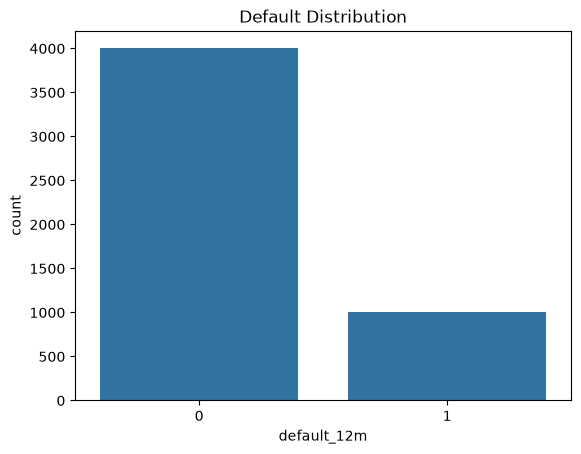

In [9]:
sns.countplot(x="default_12m", data=df)
plt.title("Default Distribution")
plt.show()

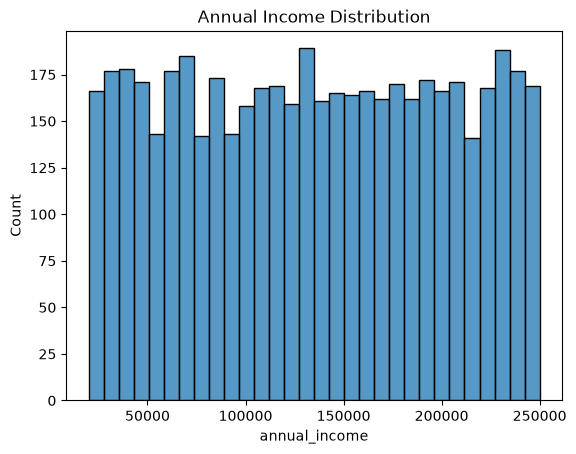

In [10]:
sns.histplot(df["annual_income"], bins=30)
plt.title("Annual Income Distribution")
plt.show()

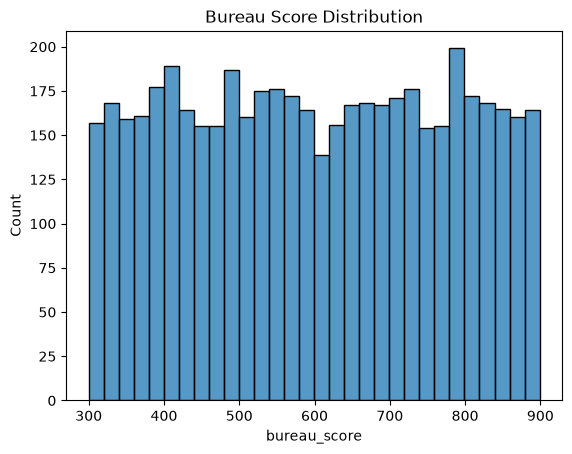

In [11]:
sns.histplot(df["bureau_score"], bins=30)
plt.title("Bureau Score Distribution")
plt.show()

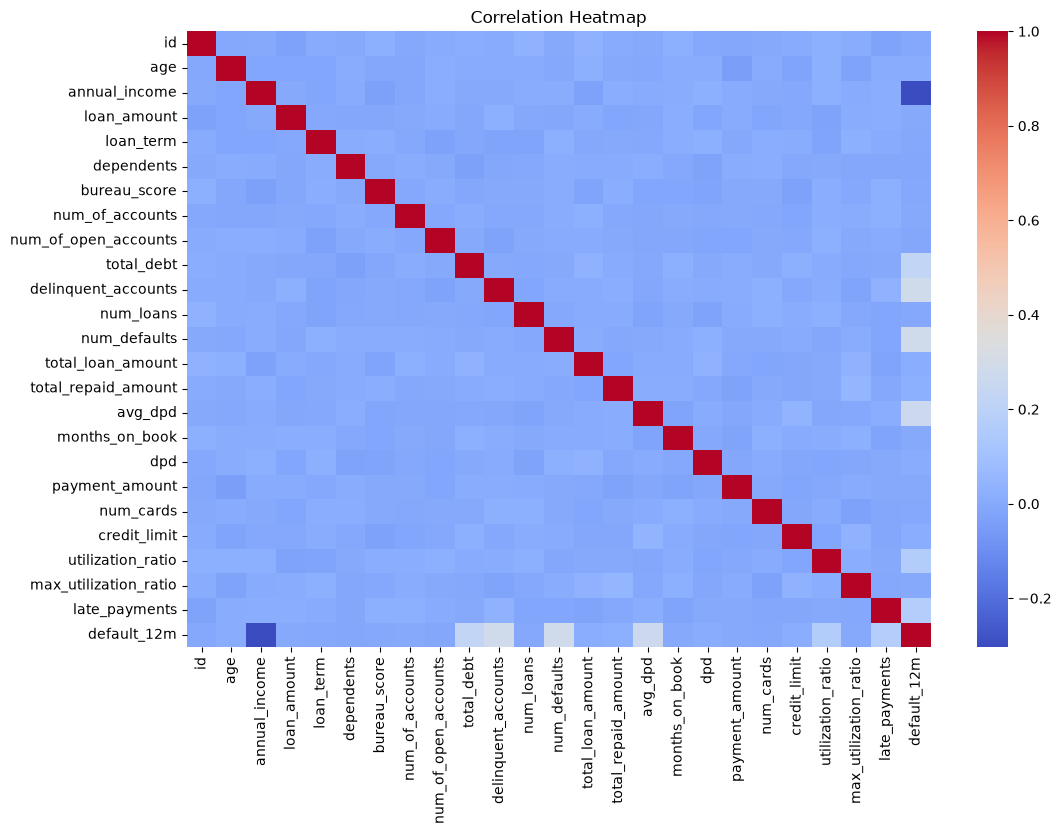

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering

Feature Engineering is performed to create meaningful variables that better represent customer financial behavior.

The following features are generated:

* Debt-to-Income Ratio
* Loan-to-Income Ratio
* Repayment Ratio
* Credit Used

These engineered features help improve model performance and enhance prediction accuracy.


In [13]:
df["debt_to_income"] = (
    df["total_debt"] /
    df["annual_income"]
)

df["loan_to_income"] = (
    df["loan_amount"] /
    df["annual_income"]
)

df["repayment_ratio"] = (
    df["total_repaid_amount"] /
    df["total_loan_amount"]
)

df["credit_used"] = (
    df["credit_limit"] *
    df["utilization_ratio"]
)

print(df.shape)

(5000, 35)


In [14]:
df[[
    "debt_to_income",
    "loan_to_income",
    "repayment_ratio",
    "credit_used"
]].head()

,debt_to_income,loan_to_income,repayment_ratio,credit_used
0,1.928600,1.394747,1.561493,47917.209011
1,1.023590,1.422650,0.484568,81589.638503
2,0.785150,0.808024,0.239609,98545.784413
3,0.121028,0.350348,2.302143,61833.460719
4,0.815808,0.436141,1.086818,78583.699433


# Data Preprocessing

Before model training, the dataset is prepared using the following preprocessing steps:

* Handling categorical variables using One-Hot Encoding
* Feature selection
* Train-Test Split
* Class balancing using SMOTE

These steps ensure that the machine learning models can effectively learn from the data.


In [15]:
categorical_cols = [
    "gender",
    "education",
    "employment_type",
    "purpose",
    "home_ownership",
    "status"
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df.shape)

(5000, 42)


In [16]:
X = df.drop(
    ["default_12m"],
    axis=1
)

y = df["default_12m"]

print(X.shape)
print(y.shape)

(5000, 41)
(5000,)


## Train-Test Split

The dataset is divided into training and testing sets.

* Training Data: 80%
* Testing Data: 20%

This allows unbiased evaluation of model performance on unseen data.


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4000, 41)
(1000, 41)


## Handling Class Imbalance using SMOTE

The target variable is imbalanced because default cases are significantly fewer than non-default cases.

SMOTE (Synthetic Minority Oversampling Technique) is applied to balance the classes and improve model learning.


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

default_12m
0    3200
1    3200
Name: count, dtype: int64


# Machine Learning Model Development

Three machine learning algorithms are trained and evaluated:

1. Logistic Regression
2. Random Forest
3. XGBoost

The objective is to identify the model that best predicts customer loan default risk.


## Logistic Regression

Logistic Regression serves as the baseline model for binary classification.

It predicts the probability that a customer will default within the next 12 months.


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train_smote)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)

### Logistic Regression Evaluation

The Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

y_prob_log = lr.predict_proba(X_test_scaled)[:, 1]

roc_auc_log = roc_auc_score(y_test, y_prob_log)
print("ROC AUC  :", roc_auc_log)

Accuracy : 0.966
Precision: 0.8807339449541285
Recall   : 0.96
F1 Score : 0.9186602870813397
ROC AUC  : 0.99479375


## Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It captures non-linear relationships and improves predictive performance compared to the baseline model.


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

### Random Forest Evaluation

The Random Forest model is evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. The results are compared with the baseline Logistic Regression model.


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_pred_rf = rf.predict(X_test)

# Prediction probabilities (THIS LINE WAS MISSING)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC AUC  :", roc_auc_rf)

Accuracy : 0.911
Precision: 0.7846153846153846
Recall   : 0.765
F1 Score : 0.7746835443037975
ROC AUC  : 0.95331875


## XGBoost

XGBoost is a powerful gradient boosting algorithm widely used in credit risk modeling.

It is expected to provide the highest predictive accuracy by effectively handling complex feature interactions.


In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

### XGBoost Evaluation

The XGBoost model is evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. This model achieved the best overall performance and was selected as the final model.


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("ROC-AUC  :", roc_auc_xgb)


Accuracy : 0.936
Precision: 0.8300970873786407
Recall   : 0.855
F1 Score : 0.8423645320197044
ROC-AUC  : 0.9828125


## Hyperparameter Tuning

GridSearchCV is used to identify the optimal combination of XGBoost parameters. Multiple parameter combinations are evaluated using 5-fold cross-validation and ROC-AUC score.

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_search.fit(
    X_train_smote,
    y_train_smote
)

print("Best Parameters:")
print(grid_search.best_params_)

best_xgb = grid_search.best_estimator_

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [26]:
y_pred_best = best_xgb.predict(X_test)

y_prob_best = best_xgb.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score

roc_auc_best = roc_auc_score(
    y_test,
    y_prob_best
)

print("Tuned XGBoost ROC-AUC:", roc_auc_best)

Tuned XGBoost ROC-AUC: 0.98506875


# Cross Validation

Cross Validation is performed to evaluate the stability and robustness of the selected model.

The dataset is divided into multiple folds, and the model is trained and tested repeatedly. The average F1 Score is used as the final validation metric.


In [27]:

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_xgb,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='roc_auc'
)

print("CV Scores:")
print(cv_scores)

print("Mean ROC-AUC:")
print(cv_scores.mean())

CV Scores:
[0.99133301 0.99743652 0.99803955 0.9980542  0.99834229]
Mean ROC-AUC:
0.9966411132812499


# Model Comparison

The performance of Logistic Regression, Random Forest, and XGBoost is compared using multiple evaluation metrics.

Among all models, XGBoost achieved the highest Accuracy, F1 Score, and ROC-AUC, making it the most suitable model for credit risk prediction.


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_best)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_best)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_best)
    ],

    "ROC-AUC": [
        roc_auc_log,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_best
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.966,0.8807,0.960,0.9187,0.9948
1,Random Forest,0.911,0.7846,0.765,0.7747,0.9533
2,XGBoost,0.936,0.8301,0.855,0.8424,0.9828
3,Tuned XGBoost,0.949,0.8634,0.885,0.8741,0.9851


# Confusion Matrix

The confusion matrix provides a detailed breakdown of prediction performance by comparing actual and predicted class labels.

It helps identify correctly classified and misclassified customers.


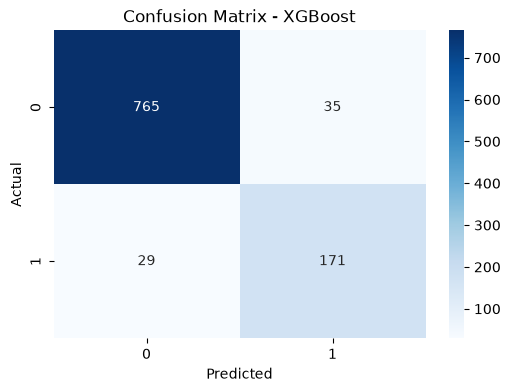

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Feature Importance Analysis

Feature Importance analysis helps identify which variables contribute most to loan default prediction.

Understanding important risk factors improves model transparency and supports business decision-making.


In [30]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
24,debt_to_income,0.148624
15,avg_dpd,0.097943
2,annual_income,0.084848
12,num_defaults,0.068556
10,delinquent_accounts,0.062683
9,total_debt,0.052307
21,utilization_ratio,0.047189
25,loan_to_income,0.044495
23,late_payments,0.037670
27,credit_used,0.025368


In [31]:
from sklearn.model_selection import GridSearchCV

# Model Explainability using SHAP

SHAP (SHapley Additive exPlanations) is used to explain model predictions.

SHAP values show how individual features influence the probability of customer default and improve trust in machine learning predictions.


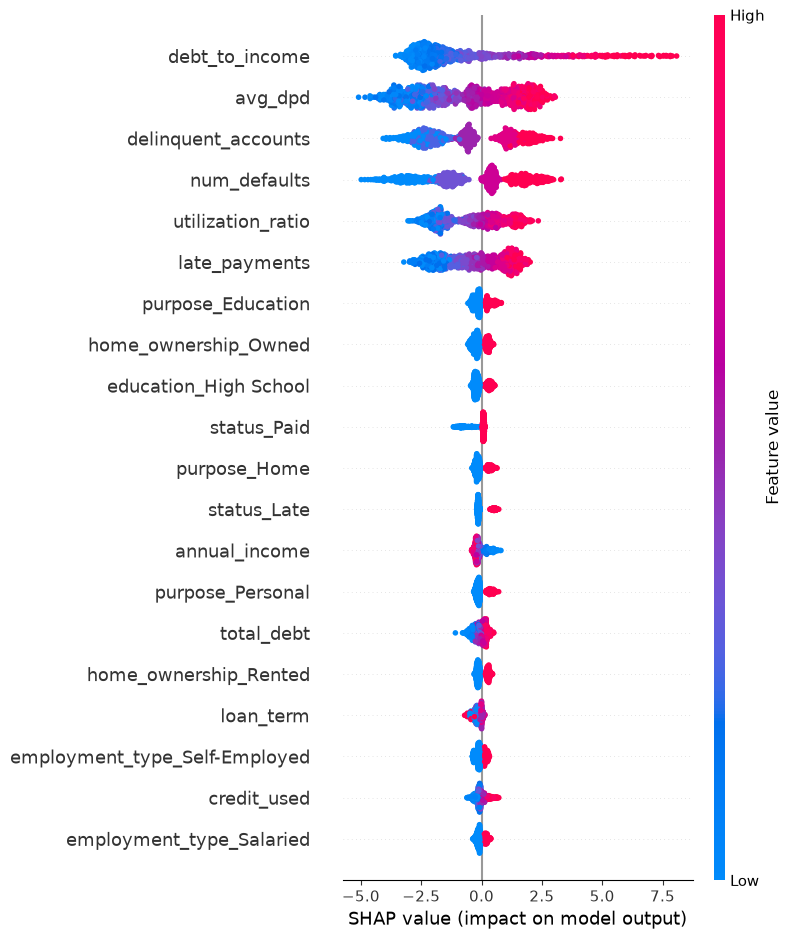

In [32]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

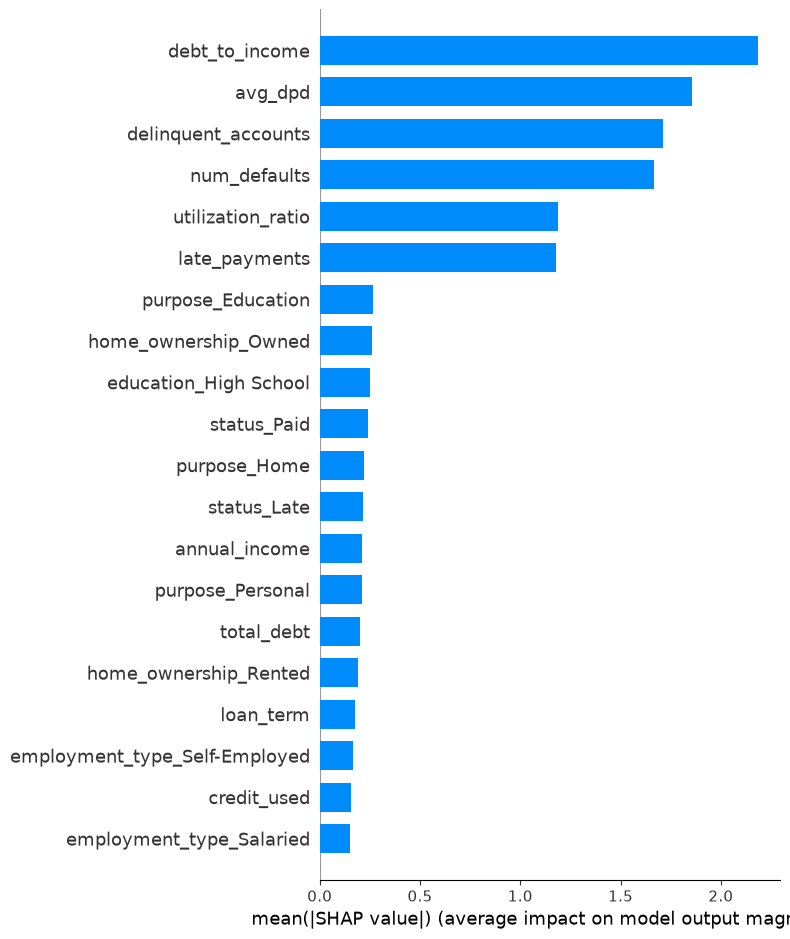

In [33]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [34]:
import joblib

joblib.dump(
    xgb,
    "data/models/credit_risk_xgboost.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "data/models/feature_columns.pkl"
)

print("Everything Saved Successfully")

Everything Saved Successfully


# Business Insights and Recommendations

## Key Risk Indicators

The analysis identified the following variables as the strongest predictors of loan default:

* Debt-to-Income Ratio
* Average DPD
* Previous Defaults
* Delinquent Accounts
* Credit Utilization Ratio

## Recommendations

### Low Risk Customers

* Approve loans quickly.
* Offer premium financial products.

### Medium Risk Customers

* Conduct manual review.
* Request additional verification documents.

### High Risk Customers

* Reject applications or request collateral.
* Apply stricter credit policies.

## Business Value

This solution helps financial institutions:

* Reduce default losses
* Improve approval efficiency
* Automate credit risk assessment
* Support data-driven lending decisions


## Recommendations

Based on the model findings and business insights, the following recommendations are proposed:

1. Integrate the tuned XGBoost model into the loan approval workflow to identify high-risk applicants early.

2. Apply stricter verification procedures for customers with low bureau scores and high debt-to-income ratios.

3. Flag applicants with multiple previous defaults, delinquent accounts, or frequent late payments for manual review.

4. Monitor customers with high credit utilization ratios, as they are more likely to experience repayment difficulties.

5. Use explainable AI techniques such as SHAP to provide transparency and support data-driven lending decisions.

6. Retrain and monitor the model periodically using updated customer data to maintain prediction accuracy and reliability.

7. Automate approvals for low-risk customers while conducting additional assessments for medium-risk applicants.

8. Continuously track model performance metrics such as ROC-AUC, Precision, Recall, and F1-Score to ensure consistent performance.

# Conclusion

This project successfully developed a Credit Risk Default Prediction System using machine learning techniques.

Three models were evaluated:

* Logistic Regression
* Random Forest
* XGBoost

Among them, XGBoost achieved the best performance:

* Accuracy: 93.6%
* Precision: 83.0%
* Recall: 85.5%
* F1 Score: 84.2%
* ROC-AUC: 98.3%

The developed Streamlit application enables real-time risk assessment and supports informed loan approval decisions.

This solution can help financial institutions reduce loan default risk and improve lending efficiency.
